# 04 Statistical Analysis

**Role:** Analysis Lead  
**Objective:** Validate findings from EDA using statistical tests to ensure insights are not due to chance.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned data
df = pd.read_csv('../data/churn_clean.csv')

# Standardize column names so tests use consistent names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)

df = df.rename(columns={
    'prev_month_end_balance': 'previous_month_end_balance',
    'avg_balance_prev_q1': 'average_monthly_balance_prevq',
    'avg_balance_prev_q2': 'average_monthly_balance_prevq2',
    'prev_month_credit': 'previous_month_credit',
    'prev_month_debit': 'previous_month_debit',
})

df.head()



,vintage,age,gender,dependents,occupation,customer_nw_category,current_balance,previous_month_end_balance,average_monthly_balance_prevq,average_monthly_balance_prevq2,...,churn,last_transaction,transaction_year,transaction_month,transaction_day,no_transaction_flag,age_group,balance_segment,total_transactions,activity_level
0,2101,66,Male,0.0,self_employed,2,1458.71,1458.71,1458.71,1449.07,...,0,2019-05-21,2019.0,5.0,21.0,0,Senior,Medium,0.40,Low Activity
1,2348,35,Male,0.0,self_employed,2,5390.37,8704.66,7799.26,12419.41,...,0,2019-11-01,2019.0,11.0,1.0,0,Adult,Medium,5486.83,Moderate
2,2194,31,Male,0.0,salaried,2,3913.16,5815.29,4910.17,2815.94,...,0,NaN,NaN,NaN,NaN,1,Adult,Medium,6047.34,Moderate
3,2329,90,Male,0.0,self_employed,2,2291.91,2291.91,2084.54,1006.54,...,1,2019-08-06,2019.0,8.0,6.0,0,Senior,Medium,0.94,Low Activity
4,1579,42,Male,2.0,self_employed,3,927.72,1401.72,1643.31,1871.12,...,1,2019-11-03,2019.0,11.0,3.0,0,Middle Age,Low,588.95,Low Activity


## 1. Hypothesis Testing: Balance vs Churn

**H0:** There is no significant difference in the average balance of churned and non-churned customers.  
**H1:** Churned customers have significantly different average balances.

In [2]:
# Filter out rows with missing churn if any
temp_df = df.dropna(subset=['churn', 'current_balance'])

churned_balance = temp_df[temp_df['churn'] == 1]['current_balance']
non_churned_balance = temp_df[temp_df['churn'] == 0]['current_balance']

t_stat, p_val = stats.ttest_ind(churned_balance, non_churned_balance, equal_var=False)

print(f"T-Statistic: {t_stat}")
print(f"P-Value: {p_val}")

if p_val < 0.05:
    print("Result: Reject the Null Hypothesis (Statistically Significant Differences)")
else:
    print("Result: Fail to Reject the Null Hypothesis")


T-Statistic: -19.26075319633176
P-Value: 5.614604314278993e-81
Result: Reject the Null Hypothesis (Statistically Significant Differences)


## 2. Chi-Square Test: Gender vs Churn

**H0:** Churn is independent of Gender.  
**H1:** Churn is dependent on Gender.

In [3]:
# Drop missing gender values for the test
temp_df = df.dropna(subset=['gender', 'churn'])

contingency_table = pd.crosstab(temp_df['gender'], temp_df['churn'])
chi2, p, dof, ex = chi2_contingency(contingency_table)

print(f"Chi-Square Statistic: {chi2}")
print(f"P-Value: {p}")

if p < 0.05:
    print("Result: Gender and Churn are dependent (Significant Relationship)")
else:
    print("Result: No significant relationship found Between Gender and Churn")


Chi-Square Statistic: 11.862741137017077
P-Value: 0.0005726818953372824
Result: Gender and Churn are dependent (Significant Relationship)


## 3. Analysis of Variance (ANOVA): Occupation vs Balance

Does occupation influence the balance maintained by customers?

In [4]:
temp_df = df.dropna(subset=['occupation', 'current_balance'])
groups = [group['current_balance'].values for name, group in temp_df.groupby('occupation')]
f_stat, p_val = stats.f_oneway(*groups)

print(f"F-Statistic: {f_stat}")
print(f"P-Value: {p_val}")


F-Statistic: 23.497308046581566
P-Value: 1.199494598399609e-23


## 4. Correlation with Churn

This checks the direction and strength of linear relationships between numeric features and churn.


Correlation with Churn:
current_balance        -0.1048
age                    -0.0200
dependents              0.0293
current_month_credit    0.0581
total_transactions      0.1372
current_month_debit     0.1859
dtype: float64


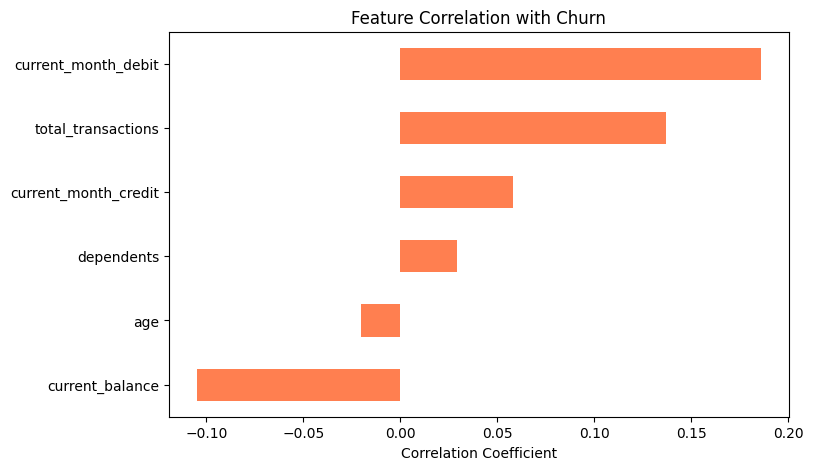

In [5]:
numeric_cols = [
    'current_balance',
    'age',
    'total_transactions',
    'dependents',
    'current_month_credit',
    'current_month_debit'
]

correlation = df[numeric_cols].corrwith(df['churn'])

print('Correlation with Churn:')
print(correlation.sort_values().round(4))

# Visual
correlation.sort_values().plot(kind='barh', color='coral', figsize=(8, 5))
plt.title('Feature Correlation with Churn')
plt.xlabel('Correlation Coefficient')
plt.show()



## 5. Conclusion

### Statistically Significant Findings

1. **Balance vs Churn (T-Test)**
   - P-Value: 5.61e-81, which is far below 0.05.
   - Result: Churned customers have significantly lower current balances.
   - Business Insight: Low balance is a strong churn-risk signal.

2. **Gender vs Churn (Chi-Square Test)**
   - P-Value: 0.00057, which is below 0.05.
   - Result: Gender and churn are statistically related.
   - Business Insight: Retention campaigns can be analyzed and customized by gender segment.

3. **Occupation vs Balance (ANOVA)**
   - P-Value: 1.20e-23, which is far below 0.05.
   - Result: Occupation significantly affects the balance maintained by customers.
   - Business Insight: Different occupation groups may need different banking products and retention offers.

4. **Correlation with Churn**
   - Current balance has a negative relationship with churn.
   - Current month debit and total transaction activity have positive relationships with churn.
   - Business Insight: Churn risk is linked not only to low balance, but also to transaction behavior that may indicate customers withdrawing or shifting money.

### Key Drivers of Churn

- Low current balance
- Gender
- Occupation type
- High debit and transaction behavior
